**Previously on:** Lecture 22 fit a genuinely nonlinear model with `curve_fit` and showed
it's `minimize` on squared error underneath. Lectures 23-24 moved from one input to
several, and learned to look at the result as a surface. Today: two fresh worked examples
covering both skills, back to back, then Quiz 5.

Today's topics:
* one more nonlinear-fit rep, on a fresh functional form -- absorbing the extra practice
  Lecture 22's density didn't have room for
* one full multivariate fit-and-visualize example
* Quiz 5, in class

> This is the fourth Examples + Quiz checkpoint (after L6, L13, L21). Quiz 5 is given in
> class today; HW8 is due this week.

# Today's skill checklist

1. Recognize when a scatter needs a genuinely nonlinear functional form, not a line or
   polynomial.
2. Define a Python model function `def model(x, a, b, ...)` for a chosen nonlinear shape.
3. Fit it with `curve_fit`, and know that `minimize` on a hand-written sum-of-squared-
   residuals function gives the same answer -- Lecture 22's through-line.
4. Set up a multivariate regression with more than one predictor column and read off
   multiple coefficients.
5. Explain what one coefficient means in a multivariate model ("holding the other inputs
   fixed...").
6. Read a 3D scatter of real data, and a `meshgrid`+`contourf` surface of a fitted
   prediction, across two inputs.

No new syntax appears in today's examples that isn't on this list -- and none of it is new
to Quiz 5.

# Worked example A: a fresh nonlinear fit on the compression data

`compression_test.csv` again -- but Lecture 22 fit a bilinear (toe + loading-stiffness)
model to it. Today's a genuinely different shape: reload and look with fresh eyes.

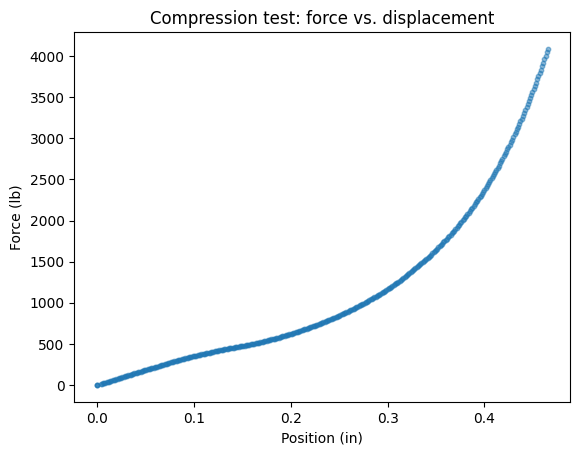

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# read directly by filename (not the shared dataset_compression_test include) --
# Worked Example B below also needs a `data`-shaped variable for the 3D-printing CSV,
# and two `include:` directives would clobber the same variable name. Same local/GitHub
# fallback search the dataset modules use, so this cell runs unchanged in Colab or locally.
_file = 'compression_test.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    compression = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

compression *= -1
compression -= compression.iloc[0, :]
compression.columns = ['position_in', 'force_lb']

plt.scatter(compression['position_in'], compression['force_lb'], s=10, alpha=0.5)
plt.xlabel('Position (in)'); plt.ylabel('Force (lb)')
plt.title('Compression test: force vs. displacement')
plt.show()

Would a straight line fit this? A parabola? The curve accelerates -- force grows faster
than displacement, especially past mid-range. That's not "add polynomial terms," it's a
genuinely nonlinear shape: try a **power law**, `F = a * x^n`.

a = 22704.9, n = 2.40


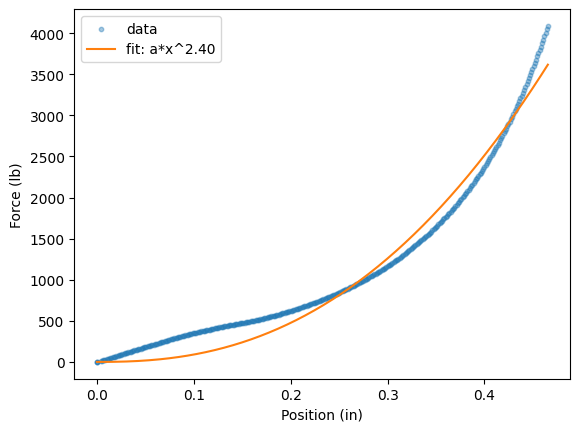

In [2]:
def power_model(x, a, n):
    return a * x**n

params, _ = optimize.curve_fit(power_model, compression['position_in'], compression['force_lb'],
                                p0=[1000, 2])
a_fit, n_fit = params
print(f'a = {a_fit:.1f}, n = {n_fit:.2f}')

xx = np.linspace(0, compression['position_in'].max(), 200)
plt.scatter(compression['position_in'], compression['force_lb'], s=10, alpha=0.4, label='data')
plt.plot(xx, power_model(xx, *params), color='C1', label=f'fit: a*x^{n_fit:.2f}')
plt.xlabel('Position (in)'); plt.ylabel('Force (lb)')
plt.legend(); plt.show()

`p0` again a required starting guess, the single biggest new-syntax item versus linear
fitting. `a ≈ 22705`, `n ≈ 2.40`, a strong fit on the bulk of the curve -- but check the
very start, where displacement is smallest:

In [3]:
near_toe = compression[compression['position_in'].between(0.045, 0.055)]
pred_toe = power_model(near_toe['position_in'], *params)
print('near x=0.05: predicted ≈ %.1f lb, actual ≈ %.1f lb' % (pred_toe.iloc[0], near_toe['force_lb'].iloc[0]))

near x=0.05: predicted ≈ 14.1 lb, actual ≈ 166.9 lb


Off by an order of magnitude at the toe -- the fit is pulled toward the large, high-force
points, so it badly *underpredicts* the low-displacement region. This is a genuine,
useful lesson about SSE-based fits weighting large residuals more: a great overall R² can
still hide a systematically-wrong region, the same caution Lecture 20 raised about
training error.

Reinforce Lecture 22's equivalence -- fit the same model by hand with `minimize`:

In [4]:
def sse(params):
    a, n = params
    pred = power_model(compression['position_in'], a, n)
    return np.sum((compression['force_lb'] - pred)**2)

result = optimize.minimize(sse, x0=[1000, 2], method='Nelder-Mead')
print(result.x)   # compare to params from curve_fit above
print(params)

resid = compression['force_lb'] - power_model(compression['position_in'], *params)
r2 = 1 - np.var(resid) / np.var(compression['force_lb'])
print('R^2 =', r2)

[2.27052313e+04 2.40207431e+00]
[2.27049346e+04 2.40206034e+00]
R^2 = 0.9747798582859782


Matching parameter vectors, up to solver tolerance -- exactly the takeaway from Lecture
22, reinforced on a second dataset shape: `curve_fit` is doing exactly this, minimizing
sum of squared residuals, it just writes the residual function for you and picks a solver
tuned for exactly this kind of problem. (`method='Nelder-Mead'` is specified deliberately
-- the default solver reports a spurious "not converged" warning on this particular
surface despite landing on essentially the same answer.)

One more sentence, no new code: we never used `np.polyfit` here. Polynomials are one
*family* of nonlinear-looking curves, but a nonlinear *model* means any functional form
whose parameters don't enter linearly -- `curve_fit`/`minimize` handle all of them the
same way.

# Worked example B: multivariate fit + a 3D look

Same 3D-printing dataset from Lectures 23-24, fresh predictors: does tensile strength
depend on more than one process setting at once?

In [5]:
_file2 = '3dprinting.csv'
_github2 = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file2}'
_local2 = next(
    (p for p in (f'datasets/{_file2}', f'../datasets/{_file2}', f'../../datasets/{_file2}', f'../../../datasets/{_file2}')
     if os.path.exists(p)),
    None,
)

try:
    printer = pd.read_csv(_local2 if _local2 else _github2)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file2}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github2}"
    ) from e

printer[['infill_density (%)', 'layer_height (mm)', 'nozzle_temperature (degC)',
         'tension_strength (Mpa)']].describe()

,infill_density (%),layer_height (mm),nozzle_temperature (degC),tension_strength (Mpa)
count,50.00000,50.000000,50.000000,50.000000
mean,53.40000,0.106000,221.500000,20.080000
std,25.36348,0.064397,14.820353,8.925634
min,10.00000,0.020000,200.000000,4.000000
25%,40.00000,0.060000,210.000000,12.000000
50%,50.00000,0.100000,220.000000,19.000000
75%,80.00000,0.150000,230.000000,27.000000
max,90.00000,0.200000,250.000000,37.000000


In [6]:
class LinearModel:
    def __init__(self, coeffs):
        self.coeffs = coeffs

    def predict(self, x):
        X = np.column_stack([np.ones(len(x)), np.asarray(x)])
        return X.dot(self.coeffs)


def fit_linear(x, y):
    X = np.column_stack([np.ones(len(x)), np.asarray(x)])
    coeffs, *_ = np.linalg.lstsq(X, np.asarray(y), rcond=None)
    return LinearModel(coeffs)


features = ['infill_density (%)', 'layer_height (mm)', 'nozzle_temperature (degC)']
x = printer[features]
y = printer['tension_strength (Mpa)']

model = fit_linear(x, y)
y_pred = model.predict(x)
r2 = 1 - np.sum((y.to_numpy() - y_pred)**2) / np.sum((y.to_numpy() - y.mean())**2)

print('intercept:', model.coeffs[0])
for name, c in zip(features, model.coeffs[1:]):
    print(f'{name}: {c:.3f}')
print('R^2:', r2)

intercept: 75.5624330751262
infill_density (%): 0.169
layer_height (mm): 46.646
nozzle_temperature (degC): -0.314
R^2: 0.4978543087910491


`infill_density` -> +0.17 MPa/%, `layer_height` -> +46.6 MPa/mm, `nozzle_temperature` ->
-0.31 MPa/degC, R² ≈ 0.50. Read the coefficients out loud, Lecture 23-style: "holding
layer height and nozzle temperature fixed, each 1% increase in infill density changes
predicted tensile strength by about +0.17 MPa." The `layer_height` coefficient looks huge
only because its raw values are tiny (mm, not %/degC) -- coefficient size alone doesn't
mean "most important input" unless the inputs are on comparable scales, exactly Lecture
23's standardization caveat. R² ≈ 0.50 is genuinely modest here: three process variables
don't fully explain FDM tensile strength (infill *pattern* and *material* are categorical
and left out) -- an honest number, not inflated by adding more features just to chase R².

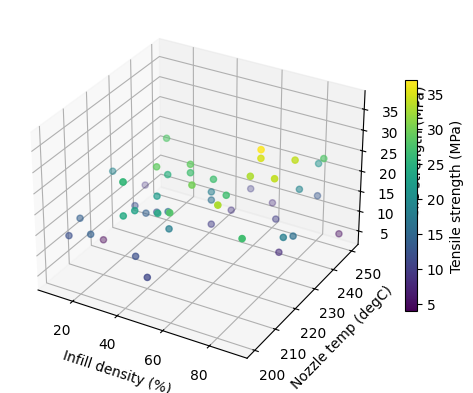

In [7]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
sc = ax.scatter(printer['infill_density (%)'], printer['nozzle_temperature (degC)'],
                 printer['tension_strength (Mpa)'], c=printer['tension_strength (Mpa)'],
                 cmap='viridis')
ax.set_xlabel('Infill density (%)'); ax.set_ylabel('Nozzle temp (degC)')
ax.set_zlabel('Tensile strength (MPa)')
plt.colorbar(sc, shrink=0.6, label='Tensile strength (MPa)')
plt.show()

The Lecture 24 callback: two predictors on the floor, the output as height and color --
the same 3D-scatter idea, now applied to a fresh feature pair. That scatter shows the real
data; Lecture 24's actual skill was gridding a *fitted* surface, so do that once more here
-- grid two of the three fitted features, hold the third at its mean, and read the fit as
a contour:

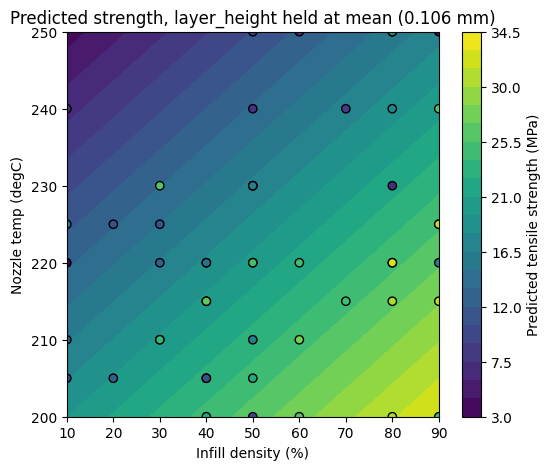

In [8]:
inf_lin = np.linspace(x['infill_density (%)'].min(), x['infill_density (%)'].max(), 50)
noz_lin = np.linspace(x['nozzle_temperature (degC)'].min(), x['nozzle_temperature (degC)'].max(), 50)
INF, NOZ = np.meshgrid(inf_lin, noz_lin)
lh_mean = x['layer_height (mm)'].mean()
grid = np.column_stack([INF.ravel(), np.full(INF.size, lh_mean), NOZ.ravel()])
Z_pred = model.predict(grid).reshape(INF.shape)

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(INF, NOZ, Z_pred, levels=20, cmap='viridis')
plt.colorbar(cs, label='Predicted tensile strength (MPa)')
ax.scatter(printer['infill_density (%)'], printer['nozzle_temperature (degC)'],
           c=printer['tension_strength (Mpa)'], edgecolor='k', cmap='viridis')
ax.set_xlabel('Infill density (%)'); ax.set_ylabel('Nozzle temp (degC)')
ax.set_title(f'Predicted strength, layer_height held at mean ({lh_mean:.3f} mm)')
plt.show()

Reading check: where does the filled contour's color disagree most with the scattered
points' color -- near the middle of the cloud, or out toward the plot's edges? What does
that pattern tell you about where this fitted surface should actually be trusted?

# Rapid-fire recap: common mistakes

Back through the skill checklist -- one common bug per item:
* Forgetting `p0` in `curve_fit` and getting a solver failure or a nonsense fit -- unlike
  `polyfit`, which never needs a starting guess.
* Confusing "nonlinear model" with "polynomial" -- a cubic still fits the way `polyfit`
  fits a line, while a power law/exponential needs `curve_fit`/`minimize`.
* Passing a single 1D feature where a multivariate fit expects a full table of columns.
* Misreading a multivariate coefficient as "the effect of X on y" without the "holding
  everything else fixed" qualifier.
* Mixing up which axis is which in a 3D scatter and misreading the plot as a result.

# Quiz 5 (in class)

Quiz 5 is administered separately from this notebook -- closed-notes, scoped exactly to
today's six-item skill checklist, on a small excerpt of `3dprinting.csv` with an unseen
predictor combination, so it tests transfer, not memorized numbers from today.

# Wrap-up

* A nonlinear fit's overall R² can hide a systematically-wrong region -- check the parts
  of the curve the fit is pulled away from, not just the summary number.
* `curve_fit` and `minimize` agree, every time, on any model this module has used.
* A multivariate coefficient means "per-unit effect, holding the rest fixed" -- read it
  with that qualifier every time, and check units before comparing coefficient sizes.

**Take-home message:** today's two examples used no syntax you hadn't already seen in
Lectures 22-24 -- fitting and visualizing a genuinely new dataset is the same handful of
steps, over and over, not a new thing to learn each time.

Next class: Lecture 26 covers the last model type this course teaches, k-nearest
neighbors -- what to do when the target you're predicting is a category, not a number.